In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [20]:
# ==========================================
# 0. Config
# ==========================================
CONFIG = {
    'file_path': 'Adidas_US_Sales_Dataset.csv',
    'date_col': 'invoicedate',
    'target_col': 'totalsales',
    'look_back': 14,             
    'batch_size': 16,
    'epochs': 200,
    'learning_rate': 0.001, 
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}
print(f"Using device: {CONFIG['device']}")

Using device: cpu


In [21]:
# ==========================================
# 1. Data Cleaning
# ==========================================
def load_and_clean_data(config):
    try:
        df = pd.read_csv(config['file_path'], sep=None, engine='python')
    except Exception as e:
        df = pd.read_csv(config['file_path']) 
        
    df.columns = df.columns.str.lower().str.replace(' ', '')
    
    if df[config['target_col']].dtype == 'object':
        df[config['target_col']] = df[config['target_col']].astype(str).str.replace(r'[$\s,]', '', regex=True)
        df[config['target_col']] = pd.to_numeric(df[config['target_col']])

    df[config['date_col']] = pd.to_datetime(df[config['date_col']], format='%d/%m/%Y', errors='coerce')
    if df[config['date_col']].isnull().all():
        df[config['date_col']] = pd.to_datetime(df[config['date_col']])

    daily_df = df.groupby(config['date_col'])[config['target_col']].sum().reset_index()
    daily_df = daily_df.set_index(config['date_col'])
    daily_df = daily_df.resample('D').sum().fillna(0)
    daily_df = daily_df.reset_index()

    return daily_df

df_clean = load_and_clean_data(CONFIG)

In [22]:
# ==========================================
# 2. Feature Engineering
# ==========================================
def process_features(df, config):
    data = df.copy()
    target = config['target_col']

    smooth_col = f"{target}_smooth"
    data[smooth_col] = data[target].ewm(span=7, adjust=False).mean()

    data['lag_1'] = data[smooth_col].shift(1)
    data['lag_7'] = data[smooth_col].shift(7)

    date_series = data[config['date_col']]
    data['month_sin'] = np.sin(2 * np.pi * date_series.dt.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * date_series.dt.month / 12)
    data['day_sin'] = np.sin(2 * np.pi * date_series.dt.dayofweek / 7)
    data['day_cos'] = np.cos(2 * np.pi * date_series.dt.dayofweek / 7)

    data.dropna(inplace=True)
    feature_cols = [smooth_col, 'lag_1', 'lag_7', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

    return data, feature_cols

df_processed, feature_cols = process_features(df_clean, CONFIG)

In [23]:
# ==========================================
# 3. Sliding Window & Covariates
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
data_values = df_processed[feature_cols].values
data_scaled = scaler.fit_transform(data_values)

def create_dataset_with_covariates(dataset, look_back):
    X_hist, X_target_cov, Y = [], [], []
    for i in range(len(dataset) - look_back):
        # Historical data for the past look_back days
        X_hist.append(dataset[i: i + look_back])
        
        # (month_sin, month_cos, day_sin, day_cos)
        X_target_cov.append(dataset[i + look_back, 3:7])
        
        # (Delta)
        delta_y = dataset[i + look_back, 0] - dataset[i + look_back - 1, 0]
        Y.append(delta_y)  
    return np.array(X_hist), np.array(X_target_cov), np.array(Y)

X_hist, X_target_cov, y = create_dataset_with_covariates(data_scaled, CONFIG['look_back'])

train_size = int(len(X_hist) * 0.85)

# Tensor
X_train_hist = torch.FloatTensor(X_hist[:train_size]).to(CONFIG['device'])
X_train_cov = torch.FloatTensor(X_target_cov[:train_size]).to(CONFIG['device'])
y_train = torch.FloatTensor(y[:train_size]).unsqueeze(1).to(CONFIG['device'])

X_test_hist = torch.FloatTensor(X_hist[train_size:]).to(CONFIG['device'])
X_test_cov = torch.FloatTensor(X_target_cov[train_size:]).to(CONFIG['device'])
y_test = torch.FloatTensor(y[train_size:]).unsqueeze(1).to(CONFIG['device'])

train_loader = DataLoader(TensorDataset(X_train_hist, X_train_cov, y_train), batch_size=CONFIG['batch_size'], shuffle=True)

In [24]:
# ==========================================
# 4. Minimalist LSTM
# ==========================================
class SimpleLSTM_Covariates(nn.Module):
    def __init__(self, num_features, hidden_size=32, num_target_covariates=4):
        super(SimpleLSTM_Covariates, self).__init__()
        
        # A minimalist LSTM with very few parameters, designed to prevent overfitting and ‘short-circuiting’
        self.lstm = nn.LSTM(
            input_size=num_features, 
            hidden_size=hidden_size, 
            num_layers=1,             
            batch_first=True
        )
        
        # Recurrent layer: Combining the temporal features extracted by the LSTM with tomorrow’s covariates
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size + num_target_covariates, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_hist, x_target_cov):
        # lstm_out shape: [Batch, Length, Hidden_size]
        lstm_out, (h_n, c_n) = self.lstm(x_hist)
        
        # Use the latent state from the last time step as a summary of historical features
        last_hidden = h_n[-1] 
        
        final_combined = torch.cat((last_hidden, x_target_cov), dim=1)
        
        delta = self.regressor(final_combined)
        return delta

In [25]:
# ==========================================
# 5. Training
# ==========================================
model = SimpleLSTM_Covariates(
    num_features=X_train_hist.shape[2], 
    hidden_size=32, 
    num_target_covariates=4
).to(CONFIG['device'])

# Switch back to MSE in conjunction with a small model to force the prediction of the true amplitude
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print("Commencing training...")
history_loss = []

for epoch in range(CONFIG['epochs']):
    model.train()
    batch_losses = []

    for batch_X_hist, batch_X_cov, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X_hist, batch_X_cov)
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_loss = np.mean(batch_losses)
    history_loss.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{CONFIG['epochs']} | Loss: {avg_loss:.6f}")

Commencing training...
Epoch 10/200 | Loss: 0.003551
Epoch 20/200 | Loss: 0.003408
Epoch 30/200 | Loss: 0.003216
Epoch 40/200 | Loss: 0.002970
Epoch 50/200 | Loss: 0.002836
Epoch 60/200 | Loss: 0.002467
Epoch 70/200 | Loss: 0.002260
Epoch 80/200 | Loss: 0.001984
Epoch 90/200 | Loss: 0.001679
Epoch 100/200 | Loss: 0.001389
Epoch 110/200 | Loss: 0.001075
Epoch 120/200 | Loss: 0.000990
Epoch 130/200 | Loss: 0.000908
Epoch 140/200 | Loss: 0.000811
Epoch 150/200 | Loss: 0.000846
Epoch 160/200 | Loss: 0.000758
Epoch 170/200 | Loss: 0.000707
Epoch 180/200 | Loss: 0.000689
Epoch 190/200 | Loss: 0.000636
Epoch 200/200 | Loss: 0.000547


In [26]:
# ==========================================
# 6. 预测与反归一化 (Evaluation)
# ==========================================
model.eval()
with torch.no_grad():
    # Test set prediction: The output is the scaled delta value
    test_pred_delta = model(X_test_hist, X_test_cov).cpu().numpy()

# Retrieve the scaled true value corresponding to "today" in the test set (i.e. the last time step in X_test_hist)
last_val_test = X_test_hist[:, -1, 0].cpu().numpy().reshape(-1, 1)

test_pred_scaled_abs = last_val_test + test_pred_delta
y_test_scaled_abs = last_val_test + y_test.cpu().numpy()

def inverse_transform(pred_array, scaler, feature_dim):
    dummy = np.zeros((len(pred_array), feature_dim))
    dummy[:, 0] = pred_array.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

# After denormalisation, the actual US dollar sales are obtained
y_test_real = inverse_transform(y_test_scaled_abs, scaler, len(feature_cols))
test_pred_real = inverse_transform(test_pred_scaled_abs, scaler, len(feature_cols))

rmse = np.sqrt(mean_squared_error(y_test_real, test_pred_real))
mae = mean_absolute_error(y_test_real, test_pred_real)
r2 = r2_score(y_test_real, test_pred_real)
print(f"\n[Test set results] RMSE: {rmse:.2f}, MAE: {mae:.2f}, R² Score: {r2:.4f}")


[Test set results] RMSE: 621644.29, MAE: 458432.70, R² Score: 0.4702


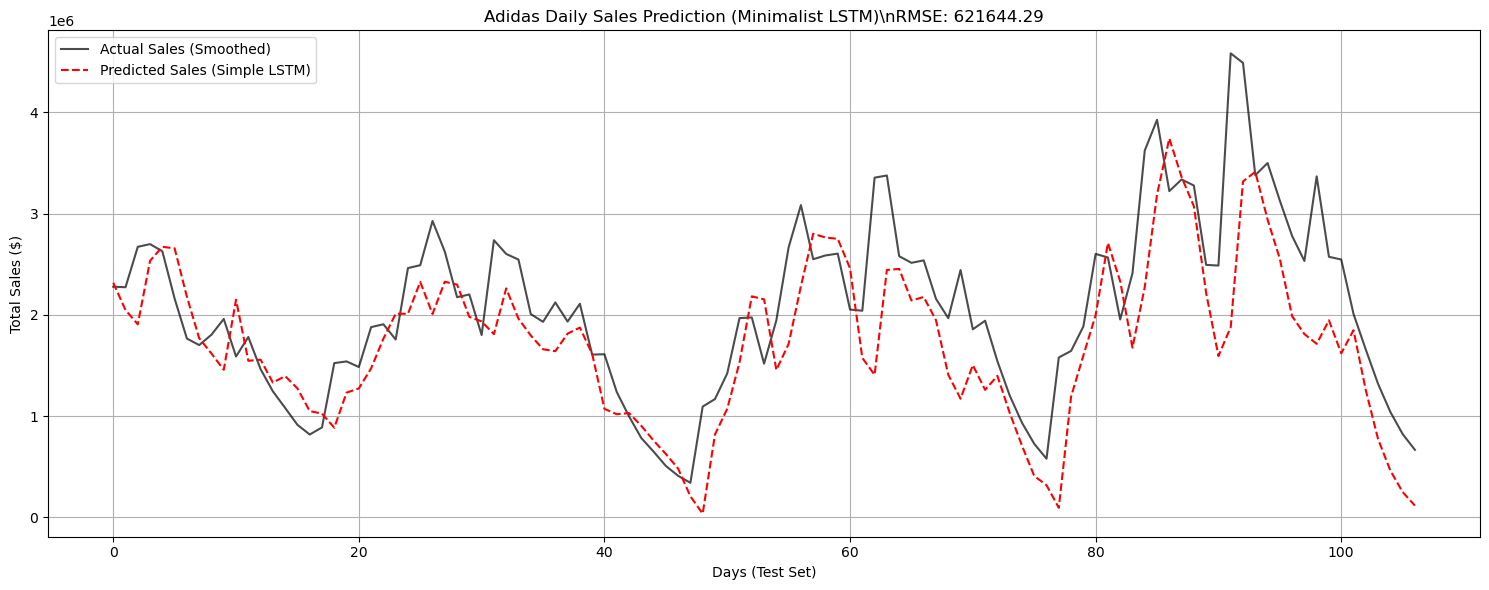

In [27]:
# ==========================================
# 7.Visualisation
# ==========================================
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Actual Sales (Smoothed)', color='black', alpha=0.7)
plt.plot(test_pred_real, label='Predicted Sales (Simple LSTM)', color='red', linestyle='--', linewidth=1.5)

plt.title(f'Adidas Daily Sales Prediction (Minimalist LSTM)\\nRMSE: {rmse:.2f}')
plt.xlabel('Days (Test Set)')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()